# Exercise - Decoupling of Printed Circuit Boards - 3)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Decoupling of Printed Circuit Boards

* Lecture Period: Summer 2024 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/overview?cid=ad2748a23022bc374228b4671f8dc508))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/institute/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Til Hillebrecht and Jan Heßling



### PCB Setup

The printed circuit board (PCB) is shown in the figure below. Having 26 ports in total $(P_1$ to $P_{26})$. Remember, python indices start at 0!
The goal is to increase the frequency where the target impedance (TI) is violated. Therefore, a few things are defined.

* The equivalent circuit of the VRM is a resistor with $50m\Omega$ (connected at $P_1$)
* Impedance of interest $(Z_{PDN})$ is observed at $P_2$ (center of the board/array)
* Remaining ports $P_3$ to $P_{26}$ are used for placing decoupling capacitor
* Decaps are chosen from a library, accessed through the helper function (*get_decap_library()*)
* Target Impedance (TI) is set to $30m\Omega$
* You can place at each port $(P_3$ to $P_{26})$ one decap from the library.




<img title="PCB for Decoupling Optimization" src='figures/pcb_setup.png' width='500'/>

In the following cell:

* First required modules are loaded
* The decap library and the bare board network parameters are loaded
* The VRM network is defined and connected to $P_1$ of the bare board

In [2]:
import helper.helper_function as hp
import matplotlib.pyplot as plt
import random as rand

decap_library = hp.get_decap_library() # get decap library
ntw_board_raw = hp.get_ntw_board("data/ntw_board_pmc.s26p") # load bare board network
ntw_vrm = hp.get_vrm_network(ntw_board_raw, l=0.0) # load VRM network
ntw_board = hp.connect_to_network(ntw_vrm, ntw_board_raw, 0) # connect VRM network to bare board

decap_library

,C,ESL,ESR
0,1.000000e-08,1.000000e-12,0.007
1,1.000000e-07,1.000000e-11,0.010
2,1.000000e-06,5.000000e-11,0.010
3,5.000000e-06,1.000000e-10,0.070
4,1.000000e-05,1.000000e-10,0.100


In the following cell the violation of the target impedance is calculated. Following parameters are required:

* The network under investigation
* The port under investigation (python index)
* the target impedance

Return values are:
* Frequency of violation
* -1 if always violated
* 0 if no violation

In [3]:
hp.get_violation_frequency(ntw_board, 1, target_impedance=0.03)

-1

In the following cell a decap is chosen from the loaded library and connected the ntw board. Here, the decap is chosen randomly.

In [9]:
decap_index = rand.randint(0, len(decap_library))
ntw_decap = hp.get_decap_network(decap_library.loc[decap_index], ntw_board=ntw_board)

ntw_decap_terminated = hp.connect_to_network(ntw_decap= ntw_decap, ntw_board = ntw_board)

decap_index

0

In the following cell the different magnitudes of network impedances at $P_2$ are plotted:
* Bare Board: NO Decaps, NO VRM
* VRM Board: NO Decaps, YES VRM
* Decap Board: YES Decap, YES VRM


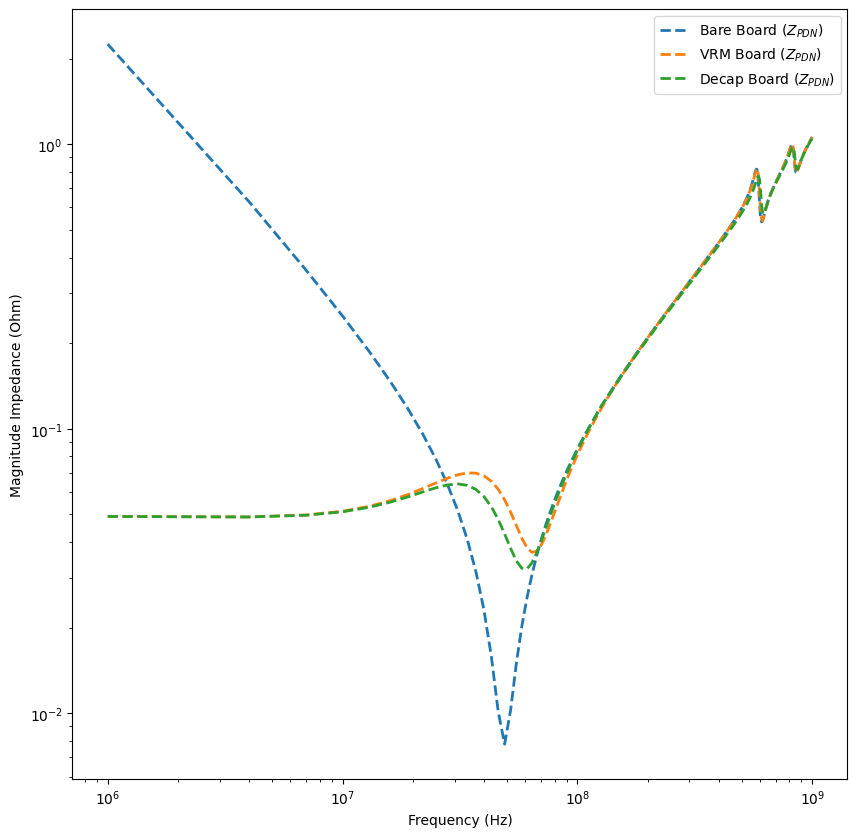

In [10]:
### code cell
import skrf as rf
fig, axs = plt.subplots(1, 1, figsize=(10,10), sharey=False)

axs.loglog(ntw_board_raw.f, abs(ntw_board_raw.z[:, 1, 1]), label='Bare Board $(Z_{PDN}$)', ls = "--", lw= 2)
axs.loglog(ntw_board.f, abs(ntw_board.z[:, 1, 1]), label='VRM Board $(Z_{PDN}$)', ls = "--", lw= 2)

axs.loglog(ntw_decap_terminated.f, abs(ntw_decap_terminated.z[:, 1, 1]), label='Decap Board $(Z_{PDN}$)', ls = "--", lw= 2)

axs.set_xlabel("Frequency (Hz)")
axs.set_ylabel("Magnitude Impedance (Ohm)")
axs.legend()
